In [2]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
import seaborn as sns

Features:

Age | Objective Feature | age | int (days)

Height | Objective Feature | height | int (cm) |

Weight | Objective Feature | weight | float (kg) |

Gender | Objective Feature | gender | categorical code |

Systolic blood pressure | Examination Feature | ap_hi | int |

Diastolic blood pressure | Examination Feature | ap_lo | int |

Cholesterol | Examination Feature | cholesterol | 1: normal, 2: above normal, 3: well above normal |

Glucose | Examination Feature | gluc | 1: normal, 2: above normal, 3: well above normal |

Smoking | Subjective Feature | smoke | binary | 0= NO ,1=Yes

Alcohol intake | Subjective Feature | alco | binary |

Physical activity | Subjective Feature | active | binary |

Presence or absence of cardiovascular disease | Target Variable | cardio | binary |

https://www.kaggle.com/datasets/akshatshaw7/cardiovascular-disease-dataset

In [3]:
data = pd.read_csv(r"C:\Users\91972\Downloads\health_data.csv\health_data.csv")
df = data.copy()
df.sample(3)
df.info()
df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   70000 non-null  int64  
 1   id           70000 non-null  float64
 2   age          70000 non-null  float64
 3   gender       70000 non-null  int64  
 4   height       70000 non-null  float64
 5   weight       70000 non-null  float64
 6   ap_hi        70000 non-null  float64
 7   ap_lo        70000 non-null  float64
 8   cholesterol  70000 non-null  int64  
 9   gluc         70000 non-null  int64  
 10  smoke        70000 non-null  int64  
 11  alco         70000 non-null  int64  
 12  active       70000 non-null  int64  
 13  cardio       70000 non-null  int64  
dtypes: float64(6), int64(8)
memory usage: 7.5 MB


Unnamed: 0     70000
id             70000
age             8076
gender             2
height           109
weight           287
ap_hi            153
ap_lo            157
cholesterol        3
gluc               3
smoke              2
alco               2
active             2
cardio             2
dtype: int64

In [4]:
# Removing the 1st two rows that are useless for the classification
df =df.drop(['Unnamed: 0','id'],axis=1) 
df.info()
# We have no missing values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  float64
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  float64
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  float64
 5   ap_lo        70000 non-null  float64
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(5), int64(7)
memory usage: 6.4 MB


In [5]:
df.sample(10,random_state=43)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
10315,16853.0,1,171.0,78.0,139.0,80.0,0,0,1,0,1,1
60149,18321.0,0,159.0,57.0,120.0,80.0,0,0,0,0,1,0
17187,17562.0,0,162.0,65.0,110.0,70.0,0,0,0,0,0,0
32211,22804.0,0,162.0,70.0,130.0,90.0,0,0,0,0,0,1
41222,21191.0,0,151.0,64.0,120.0,80.0,1,1,0,0,1,0
41152,22023.0,0,162.0,70.0,120.0,80.0,0,0,0,0,1,0
48746,22921.0,0,168.0,67.0,120.0,70.0,0,0,0,0,1,1
27590,21096.0,0,169.0,92.0,110.0,80.0,0,0,0,0,1,1
56720,22608.0,0,168.0,70.0,110.0,70.0,0,2,0,0,1,0
22386,18025.0,1,160.0,60.0,120.0,60.0,0,0,0,0,1,1


 1. The age feature is in dates - should have to convert in yrs
 2. The height feature is in cm  - need to conver in meter
 3. by useing height and weight feature calcuate BMI - weight in kg / (height in meter)^2

In [6]:
df['age'] = round(df['age']/365)
df['height'] = df['height']/100
df['BMI'] = df['weight']/((df['height'])**2)


In [7]:
df.sample(4,random_state=43)

#  Renaming column names
col_name=list(df.columns)
print(col_name )

df = df.rename(columns={'age':'age_yr','weight':'weight_kg','height':'height_m','BMI':'BMI_kg/m2'})
df

['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'BMI']


,age_yr,gender,height_m,weight_kg,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI_kg/m2
0,50.0,1,1.68,62.0,110.0,80.0,0,0,0,0,1,0,21.967120
1,55.0,0,1.56,85.0,140.0,90.0,2,0,0,0,1,1,34.927679
2,52.0,0,1.65,64.0,130.0,70.0,2,0,0,0,0,1,23.507805
3,48.0,1,1.69,82.0,150.0,100.0,0,0,0,0,1,1,28.710479
4,48.0,0,1.56,56.0,100.0,60.0,0,0,0,0,0,0,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,53.0,1,1.68,76.0,120.0,80.0,0,0,1,0,1,0,26.927438
69996,62.0,0,1.58,126.0,140.0,90.0,1,1,0,0,1,1,50.472681
69997,52.0,1,1.83,105.0,180.0,90.0,2,0,0,1,0,1,31.353579
69998,61.0,0,1.63,72.0,135.0,80.0,0,1,0,0,0,1,27.099251


In [8]:
# Checking proportion of Cario patient 
print(df['cardio'].value_counts()/df['cardio'].count())
print('Dataset is balanced')


cardio
0    0.5003
1    0.4997
Name: count, dtype: float64
Dataset is balanced


In [9]:

# Bmi is sufficient , so removing height and weight column
df= df.drop(['height_m','weight_kg'],axis=1)

In [10]:
df.sample(3)

,age_yr,gender,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI_kg/m2
16002,60.0,0,150.0,90.0,0,0,0,0,1,0,31.229454
4577,65.0,1,130.0,80.0,1,0,0,0,1,1,22.675737
55591,64.0,0,120.0,80.0,0,0,0,0,1,1,18.339100


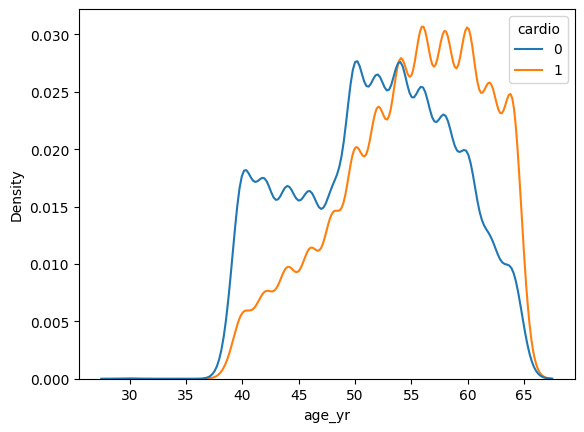

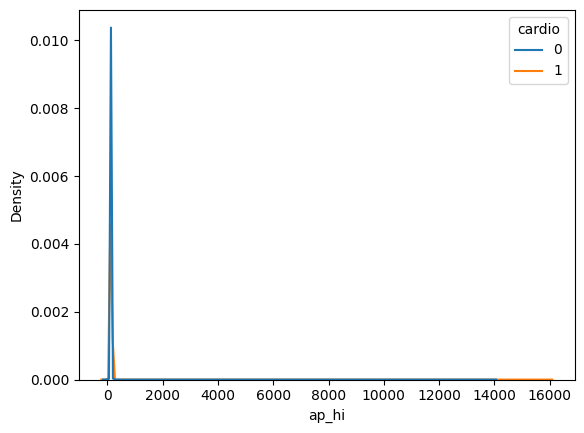

<Axes: xlabel='ap_lo', ylabel='Density'>

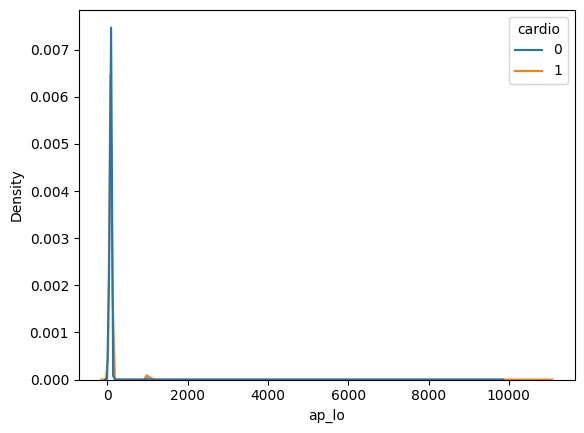

In [11]:

# print(df[['age_yr']].value_counts())
sns.kdeplot(data=df,x='age_yr',hue='cardio')
plt.show()
sns.kdeplot(data=df,x='ap_hi',hue='cardio')
plt.show()
sns.kdeplot(data=df,x='ap_lo',hue='cardio')

In [12]:
df['ap_hi'].value_counts()
df.sample()

# Investigation ap_hi , ap_lo features
# Systolic blood pressure (ap_hi)

# Range: 90 – 200 mmHg

# Diastolic blood pressure (ap_lo)

# Range: 60 – 130 mmHg

# Mandatory condition
# ap_lo < ap_hi


df[['ap_hi','ap_lo']].describe()




,ap_hi,ap_lo
count,70000.000000,70000.000000
mean,128.817286,96.630414
std,154.011419,188.472530
min,-150.000000,-70.000000
25%,120.000000,80.000000
50%,120.000000,80.000000
75%,140.000000,90.000000
max,16020.000000,11000.000000


So there are sevral rows with false values we need to investigate the,

In [13]:
df[((df['ap_hi'] < 90) | (df['ap_hi'] > 200)) & (df['ap_lo'] >= df['ap_hi'])]


# Condtn-1 Reviewing all the rows with sytolic pressue(ap_hi) < distolic pressue (ap_lo)

df[(df['ap_lo'] >= df['ap_hi']) & (df['ap_lo']>= 1000)].sample(10)

print(' On observing all the rows where the systolic bp is less than desystolic blood pressure\n I found on certain times the random sample on it \nI found that ap_lo (desystolic bp) \n is kind of typo like the values 1000,1100 are 100 ,110 \n So I will have generous value of it divivde by 10')

 On observing all the rows where the systolic bp is less than desystolic blood pressure
 I found on certain times the random sample on it 
I found that ap_lo (desystolic bp) 
 is kind of typo like the values 1000,1100 are 100 ,110 
 So I will have generous value of it divivde by 10


In [14]:
df[(df['ap_lo'] >= df['ap_hi']) & (df['ap_lo']>= 1000)] = df[(df['ap_lo'] >= df['ap_hi']) & (df['ap_lo']>= 1000)]/10


C:\Users\91972\AppData\Local\Temp\ipykernel_19224\3465433907.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.1 0.1 0.  0.  0.  0.1 0.  0.  0.  0.1 0.1 0.1 0.  0.1 0.  0.1 0.  0.1
 0.  0.1 0.1 0.1 0.  0.  0.  0.  0.1 0.1 0.1 0.  0.  0.1 0.  0.  0.  0.1
 0.1 0.  0.  0.1 0.  0.1 0.  0.  0.  0.  0.  0.1 0.  0.  0.  0.  0.  0.
 0.  0.1 0.1 0.1 0.  0.  0.1 0.1 0.  0.  0.1 0.1 0.1 0.  0.  0.  0.1 0.
 0.  0.  0.1 0.  0.  0.  0.1 0.  0.  0.  0.1 0.  0.  0.1 0.  0.  0.  0.1
 0.  0.  0.  0.  0.  0.  0.  0.1 0.  0.  0.  0.1 0.1 0.1 0.  0.  0.1 0.
 0.  0.  0.1 0.1 0.1 0.  0.  0.  0.  0.  0.  0.1 0.1 0.1 0.  0.1 0.  0.
 0.  0.1 0.  0.  0.  0.  0.1 0.1 0.  0.1 0.  0.1 0.1 0.  0.  0.1 0.1 0.1
 0.1 0.  0.  0.  0.  0.  0.1 0.1 0.1 0.1 0.1 0.  0.  0.1 0.1 0.1 0.1 0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.1 0.1 0.  0.1 0.  0.1
 0.  0.1 0.  0.1 0.1 0.1 0.  0.1 0.  0.  0.  0.  0.  0.  0.1 0.  0.  0.1
 0.  0

In [15]:
# Changing negative values to positive
# Checking whether any of the rows has 0 of either of these bp , if it then removing those rows bcz it is impossible for a living person
df[(df['ap_lo']==0)|(df['ap_hi']==0)]

df = df[((df['ap_lo']!=0) & (df['ap_hi']!=0))]

In [16]:
# Changing negative values and if they exist and by sme transformation they become reliable , will do.

print(df[(df['ap_hi']<0)|(df['ap_lo']<0)].to_string())
print("""Except the row with index 60106 all the other roads are reliable 
      we just need to convert the given value of systolic blood pressure into positive
      so which makes the row rel and we'll remove that particular row index 60106""")

# 1- convert vaues into positive then remove row 60106
df = df.drop(index=[60106])

idx_neg_bp = list(df[(df['ap_hi']<0)|(df['ap_lo']<0)].index)
df.loc[idx_neg_bp,'ap_hi']  = - df.iloc[idx_neg_bp,2]



       age_yr  gender  ap_hi  ap_lo  cholesterol  gluc  smoke  alco  active  cardio  BMI_kg/m2
4607     42.0     0.0 -100.0   80.0          1.0   0.0    0.0   0.0     1.0     0.0  28.650138
16021    61.0     1.0 -115.0   70.0          0.0   0.0    0.0   0.0     1.0     0.0  34.720883
20536    43.0     0.0 -100.0   70.0          0.0   0.0    0.0   0.0     1.0     0.0  23.068051
23988    50.0     0.0 -140.0   90.0          0.0   0.0    0.0   0.0     1.0     1.0  28.196921
25240    40.0     1.0 -120.0   80.0          1.0   0.0    0.0   0.0     0.0     1.0  17.715420
35040    64.0     1.0 -150.0   80.0          0.0   0.0    0.0   0.0     1.0     1.0  20.904195
46627    65.0     1.0 -120.0   80.0          0.0   0.0    0.0   0.0     0.0     0.0  23.046875
60106    62.0     0.0   15.0  -70.0          0.0   0.0    0.0   0.0     1.0     1.0  26.533759
Except the row with index 60106 all the other roads are reliable 
      we just need to convert the given value of systolic blood pressure into p

In [17]:
# Checking Large values of BP

df[(df['ap_hi']>100000) | (df['ap_lo']>100000)]    #no rows for this condt

df[(df['ap_hi']>10000) | (df['ap_lo']>10000)]       # Converting ap_hi
idx1=df[(df['ap_hi']>10000) | (df['ap_lo']>10000)].index
df.loc[idx1,'ap_hi'] = df.loc[idx1,'ap_hi']/100 


In [18]:

df[(df['ap_hi']>1000) | (df['ap_lo']>1000)]       # Converting ap_hi
idx2=df[(df['ap_hi']>1000) | (df['ap_lo']>1000)].index
df.loc[idx2,'ap_hi'] = df.loc[idx2,'ap_hi']/10 


In [19]:

df[(df['ap_hi']>1000) | (df['ap_lo']>1000)]       # Converting ap_hi

df=df.drop(index=df[(df['ap_hi']>1000) | (df['ap_lo']>1000)].index)

In [20]:
df.describe()

df[(df['ap_hi']>300) | (df['ap_lo']> 300)]  
df = df.drop(index=df[(df['ap_hi']>300) | (df['ap_lo']>300)].index  )

In [21]:
df.describe()

,age_yr,gender,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI_kg/m2
count,69913.000000,69913.000000,69906.000000,69913.000000,69913.000000,69913.000000,69913.000000,69913.000000,69913.000000,69913.000000,69913.000000
mean,52.710454,0.344746,124.908024,81.629126,0.360448,0.223270,0.086838,0.052992,0.794043,0.489773,27.209890
std,8.617586,0.474785,21.554698,10.078015,0.675246,0.568561,0.281368,0.223852,0.403208,0.498900,6.641613
min,3.900000,0.000000,0.100000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.367309
25%,48.000000,0.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,23.795360
50%,54.000000,0.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,26.259585
75%,58.000000,1.000000,140.000000,90.000000,0.100000,0.000000,0.000000,0.000000,1.000000,1.000000,30.110279
max,65.000000,1.000000,240.000000,208.800000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,298.666667


In [22]:
# NOW checking BMI a, its typical value must be between 10 to 100
df[(df['BMI_kg/m2'] <10) | (df['BMI_kg/m2'] >100) ]
# Removing
df = df.drop(index=df[(df['BMI_kg/m2'] <10) | (df['BMI_kg/m2'] >100)].index)

In [23]:
df.describe()

,age_yr,gender,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI_kg/m2
count,68982.000000,68982.000000,68975.000000,68982.000000,68982.000000,68982.000000,68982.000000,68982.000000,68982.000000,68982.000000,68982.000000
mean,53.325128,0.348700,126.328713,81.351483,0.364472,0.225885,0.087806,0.053579,0.803311,0.495028,27.467612
std,6.767911,0.476562,17.692722,9.800012,0.678694,0.571832,0.283014,0.225187,0.397498,0.499979,5.288523
min,30.000000,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.726644
25%,48.000000,0.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,23.875115
50%,54.000000,0.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,26.346494
75%,58.000000,1.000000,140.000000,90.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,30.119376
max,65.000000,1.000000,240.000000,190.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,95.221607


       age_yr  gender  ap_hi  ap_lo  cholesterol  gluc  smoke  alco  active  \
63406    57.0     0.0  140.0  100.0          2.0   0.0    0.0   0.0     1.0   

       cardio  BMI_kg/m2  
63406     1.0      31.25  


<Axes: xlabel='cardio', ylabel='Count'>

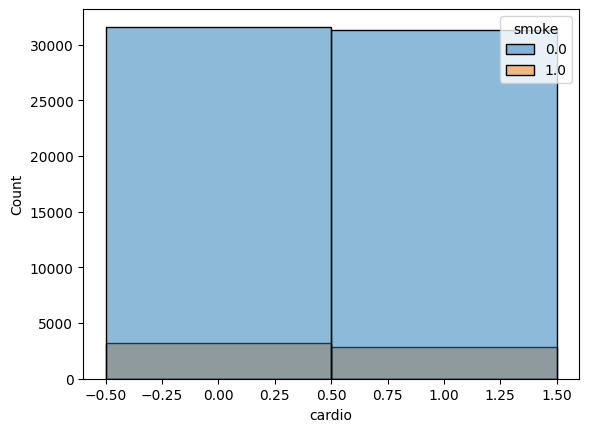

In [24]:
print(df.sample())

sns.histplot(data=df[df['cardio']==1],x='cardio',hue='smoke')    

sns.histplot(data=df[df['cardio']==0],x='cardio',hue='smoke')    

In [25]:
print(df.nunique())
df['smoke'].value_counts() # 62925 non smokers and 6057 smokers

age_yr           28
gender            2
ap_hi           126
ap_lo            93
cholesterol       3
gluc              3
smoke             2
alco              2
active            2
cardio            2
BMI_kg/m2      3752
dtype: int64


smoke
0.0    62925
1.0     6057
Name: count, dtype: int64

In [26]:
# Investing gender encoding ( by using height method - on an avg males are taller than women )
print(data.groupby('gender')[['height','weight']].mean() )
print('1 - Male,0- Female')

            height     weight
gender                       
0       161.355612  72.565605
1       169.947895  77.257307
1 - Male,0- Female


In [27]:
df.sample(3)

,age_yr,gender,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI_kg/m2
52177,52.0,0.0,180.0,110.0,1.0,0.0,0.0,0.0,1.0,1.0,32.444444
46903,60.0,1.0,140.0,90.0,0.0,0.0,0.0,0.0,1.0,0.0,28.905076
13979,52.0,0.0,110.0,80.0,1.0,0.0,0.0,0.0,1.0,0.0,32.873110


<Axes: xlabel='BMI_kg/m2', ylabel='Density'>

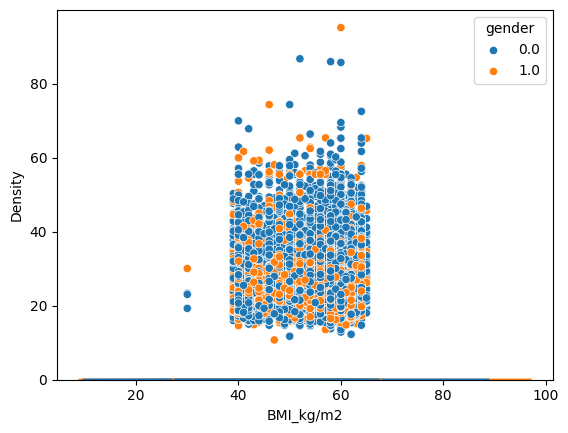

In [28]:
sns.kdeplot(data=df,x='BMI_kg/m2',hue='gender')   # Kind of Normal
sns.kdeplot(data=df,x='age_yr',hue='gender')   
sns.scatterplot(data=df,x='age_yr',y='BMI_kg/m2',hue='gender')

In [29]:

df = df.drop_duplicates()
# df.info()
df['ap_hi'].sort_values(ascending=False)
df.isna().sum()


age_yr         0
gender         0
ap_hi          7
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
BMI_kg/m2      0
dtype: int64

<Axes: xlabel='ap_lo'>

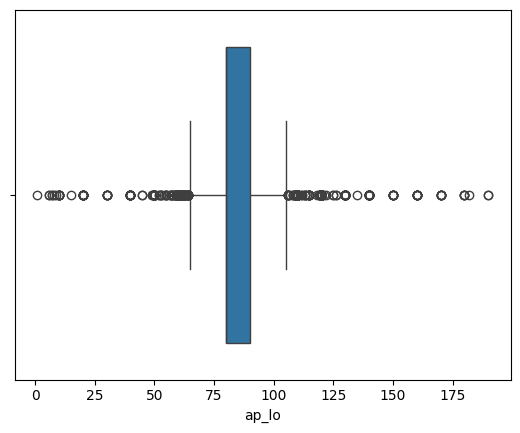

In [30]:
sns.boxplot(data=df,x='ap_lo')

In [31]:
df.describe()

,age_yr,gender,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI_kg/m2
count,65164.000000,65164.000000,65157.000000,65164.000000,65164.000000,65164.000000,65164.000000,65164.000000,65164.000000,65164.000000,65164.000000
mean,53.351222,0.356439,126.678500,81.448852,0.383755,0.237754,0.092505,0.056596,0.797097,0.508885,27.611589
std,6.811166,0.478951,18.078343,10.031297,0.690871,0.583885,0.289740,0.231070,0.402164,0.499925,5.369935
min,30.000000,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.726644
25%,48.000000,0.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,23.875115
50%,54.000000,0.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,26.566840
75%,59.000000,1.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,30.457656
max,65.000000,1.000000,240.000000,190.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,95.221607


In [32]:
df[df['ap_hi'].isna()]    # These are very few 7 missing values at random --- removing them 
df = df.dropna()
df.isna().sum()

age_yr         0
gender         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
BMI_kg/m2      0
dtype: int64

# ML MODELING
1. Logistic Regression
2. Logistic Regression + Poynmial Feature
3. Decision Trees
4. KNN
5. SVM
6. Random Forest

In [33]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(df.drop('cardio',axis=1),df['cardio'],test_size=0.2,random_state=43,stratify=df['cardio'])    # Stratify is used to maintain the same proportion of target variable in both train and test set as in original dataset
X_train.sample()

,age_yr,gender,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,BMI_kg/m2
79,56.0,1.0,140.0,85.0,0.0,0.0,0.0,0.0,0.0,27.513385


In [40]:
# Model 1
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=300,penalty='elasticnet',solver='saga',random_state=42)
gcv1 = GridSearchCV(estimator=lr,param_grid={'l1_ratio':[0,0.2,0.4,0.6,0.8,1],
                                             'C':[0.2,0.8,1,10]})
gcv1.fit(X_train,y_train)


c:\Users\91972\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\91972\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\91972\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\91972\anaconda3\Lib

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...solver='saga')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.2, 0.8, ...], 'l1_ratio': [0, 0.2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the

In [64]:

from sklearn.linear_model import LogisticRegression
gcv1 = LogisticRegression(C=0.2,l1_ratio=1,max_iter=500,penalty='elasticnet',
                          random_state=42,solver='saga')
gcv1.fit(X_train,y_train)


c:\Users\91972\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\91972\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.2
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicl

In [46]:
from sklearn.metrics import classification_report
print(gcv1.best_estimator_,'\n\n')

cr1 = classification_report(y_train,gcv1.predict(X_train))
print(cr1)

LogisticRegression(C=0.2, l1_ratio=1, max_iter=300, penalty='elasticnet',
                   random_state=42, solver='saga') 


              precision    recall  f1-score   support

         0.0       0.69      0.75      0.72     25599
         1.0       0.74      0.68      0.71     26526

    accuracy                           0.72     52125
   macro avg       0.72      0.72      0.72     52125
weighted avg       0.72      0.72      0.71     52125



In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
print(X_train.sample(1))
col_ss = X_train.iloc[:,[0,2,3,9]].columns
# Model 2
pf = PolynomialFeatures(degree=2)
ss = StandardScaler()
lr2= LogisticRegression(max_iter=500
                        )
pipe2 = Pipeline(steps=[('poly',pf),
                        ('ss',ss),
                        ('m2',lr)])

gcv2 = GridSearchCV(estimator=pipe2,param_grid={'poly__interaction_only':[True,False],
                                                'poly__include_bias':[True,False],
                                                'm2__l1_ratio':[0,0.5,0.8,1],
                                             'm2__C':[0.01,0.1,0.2,0.8]})
gcv2.fit(X_train,y_train)

       age_yr  gender  ap_hi  ap_lo  cholesterol  gluc  smoke  alco  active  \
67686    56.0     0.0  120.0   80.0          0.0   0.0    0.0   0.0     1.0   

       BMI_kg/m2  
67686  24.913495  


c:\Users\91972\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\91972\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\91972\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'m2__C': [0.01, 0.1, ...], 'm2__l1_ratio': [0, 0.5, ...], 'poly__include_bias': [True, False], 'poly__interaction_only': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each 

In [67]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

pf = PolynomialFeatures(degree=2,interaction_only=False,include_bias=True)
ss = StandardScaler()
lr2= LogisticRegression(max_iter=500,l1_ratio=1,penalty='elasticnet'
                        ,random_state=42,solver='saga',C=0.2)
pipe2 = Pipeline(steps=[('poly',pf),
                        ('ss',ss),
                        ('m2',lr2)])
pipe2.fit(X_train,y_train)


c:\Users\91972\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('ss', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [68]:
print(pipe2.best_estimator_,'\n\n')

cr2 = classification_report(y_train,pipe2.predict(X_train))
print(cr2)

AttributeError: 'Pipeline' object has no attribute 'best_estimator_'

In [54]:
# Model 3
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier(random_state=56)
gcv3 = GridSearchCV(DT,param_grid={'min_samples_split':[40,70,100],
                                   'min_samples_leaf':[10,30,50],
                                   'max_depth':[3,5,8],
                                   'max_features':[2,4,6]})
gcv3.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=56)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_features': [2, 4, ...], 'min_samples_leaf': [10, 30, ...], 'min_samples_split': [40, 70, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and p

In [78]:
from sklearn.tree import DecisionTreeClassifier
gcv3=DecisionTreeClassifier(max_depth=8,max_features=6,min_samples_leaf=30,min_samples_split=70,random_state=56)
gcv3.fit(X_train,y_train)
cr2 = classification_report(y_train,gcv3.predict(X_train))
print(cr2)

              precision    recall  f1-score   support

         0.0       0.71      0.78      0.74     25599
         1.0       0.77      0.68      0.72     26526

    accuracy                           0.73     52125
   macro avg       0.74      0.73      0.73     52125
weighted avg       0.74      0.73      0.73     52125



In [76]:
# print(gcv3.best_estimator_,'\n\n')

cr2 = classification_report(y_train,gcv3.predict(X_train))
print(cr2)

NameError: name 'gcv3' is not defined

In [56]:
# Model 4
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=45,oob_score=True)
gcv4 = GridSearchCV(rf,param_grid={'min_samples_split':[60,70,80],
                                   'min_samples_leaf':[20,30,40],
                                   'max_depth':[5,8,10],
                                   'max_features':[4,6,8],
                                   'n_estimators':[100,200,300],
                                   })
gcv4.fit(X_train,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=45)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 8, ...], 'max_features': [4, 6, ...], 'min_samples_leaf': [20, 30, ...], 'min_samples_split': [60, 70, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold 

In [199]:
# Model 4
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=45,oob_score=True,n_estimators=200)
gcv4 = GridSearchCV(rf,param_grid={'min_samples_split':[30,45,60],
                                   'max_depth':[10,13,15],
                                   'max_features':[2,3,4,len(X_train.columns)-1],
                                   })
gcv4.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=45)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 13, ...], 'max_features': [2, 3, ...], 'min_samples_split': [30, 45, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;-

In [ ]:

from sklearn.ensemble import RandomForestClassifier
# gcv4=RandomForestClassifier(max_depth=10, max_features=4, min_samples_leaf=30,
#                        min_samples_split=30, n_estimators=200,
#                        random_state=45,oob_score=True)

# print(gcv4.best_estimator_,'\n\n')
# gcv4.fit(X_train,y_train)
cr4 = classification_report(y_train,gcv4.predict(X_train))
print(cr4)

              precision    recall  f1-score   support

         0.0       0.72      0.79      0.75     25599
         1.0       0.77      0.70      0.73     26526

    accuracy                           0.74     52125
   macro avg       0.75      0.74      0.74     52125
weighted avg       0.75      0.74      0.74     52125



In [57]:
print(gcv4.best_estimator_,'\n\n')

cr4 = classification_report(y_train,gcv4.predict(X_train))
print(cr4)

RandomForestClassifier(max_depth=10, max_features=4, min_samples_leaf=30,
                       min_samples_split=60, n_estimators=200, oob_score=True,
                       random_state=45) 


              precision    recall  f1-score   support

         0.0       0.72      0.78      0.75     25599
         1.0       0.77      0.70      0.73     26526

    accuracy                           0.74     52125
   macro avg       0.74      0.74      0.74     52125
weighted avg       0.74      0.74      0.74     52125



In [72]:
# Model 5 
from sklearn.naive_bayes import CategoricalNB
cnb = CategoricalNB()
cnb.fit(X_train,y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None


In [ ]:

cr5 = classification_report(y_train,cnb.predict(X_train))
print(cr5)

              precision    recall  f1-score   support

         0.0       0.69      0.78      0.73     25599
         1.0       0.76      0.67      0.71     26526

    accuracy                           0.72     52125
   macro avg       0.73      0.72      0.72     52125
weighted avg       0.73      0.72      0.72     52125



In [52]:
# Model 6

from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
svc = SVC(kernel='rbf',random_state=43,C=10,gamma=0.1)
svc.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [219]:
from sklearn.model_selection import cross_val_score
score = cross_val_score(svc,X_train,y_train,cv=5,scoring='precision')
score.mean()

np.float64(0.7252710880823616)

In [55]:
# print(svc.best_estimator_,'\n\n')

cr6 = classification_report(y_train,svc.predict(X_train))
print(cr6)

              precision    recall  f1-score   support

         0.0       0.78      0.85      0.81     25599
         1.0       0.84      0.76      0.80     26526

    accuracy                           0.80     52125
   macro avg       0.81      0.80      0.80     52125
weighted avg       0.81      0.80      0.80     52125



In [198]:
# Model 7
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
GBC = GradientBoostingClassifier(loss='log_loss',random_state=89,n_estimators=300,subsample=1)
gcv7 = GridSearchCV(GBC, param_grid={
                                     'learning_rate':[0.3,0.5,0.7,1.2,2],
                                      'max_depth':[5,7,9,12]},cv=3
)
gcv7.fit(X_train,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","GradientBoost..., subsample=1)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.3, 0.5, ...], 'max_depth': [5, 7, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;

In [216]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
gcv7 = GradientBoostingClassifier(loss='log_loss',random_state=89,n_estimators=300,max_depth=5,subsample=0.7,learning_rate=0.3)
gcv7.fit(X_train,y_train) 

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.3
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.7
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [217]:
from sklearn.model_selection import cross_val_score
# print(gcv7.best_estimator_,'\n\n')
from sklearn.metrics import classification_report
cr7 = classification_report(y_train,gcv7.predict(X_train))
print(cr7)
# score.mean()

              precision    recall  f1-score   support

         0.0       0.77      0.82      0.79     25599
         1.0       0.81      0.76      0.79     26526

    accuracy                           0.79     52125
   macro avg       0.79      0.79      0.79     52125
weighted avg       0.79      0.79      0.79     52125



In [218]:

score = cross_val_score(gcv7,X_train,y_train,cv=5,scoring='precision')
score.mean()

np.float64(0.7290218255129695)

In [88]:
#Model 8
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
knn = KNeighborsClassifier(5)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

ct = ColumnTransformer(transformers=[('ss',StandardScaler(),['age_yr','ap_hi','ap_lo','BMI_kg/m2'])],remainder='passthrough')
pipe8 =Pipeline(steps=[('ss',ct),
                       ('m8',knn)])
gcv8 = GridSearchCV(pipe8,param_grid={'m8__n_neighbors': [5,9,13,15],
                                        'm8__weights': ['uniform', 'distance'] ,
                                        'm8__leaf_size': [30,40,70],})
gcv8.fit(X_train,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'m8__leaf_size': [30, 40, ...], 'm8__n_neighbors': [5, 9, ...], 'm8__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is 

In [89]:
gcv8=gcv8.best_estimator_

In [90]:

gcv8.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ss', ...), ('m8', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ss', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrice

In [45]:
#Model 8
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
knn = KNeighborsClassifier(5)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

ct = ColumnTransformer(transformers=[('ss',StandardScaler(),['age_yr','ap_hi','ap_lo','BMI_kg/m2'])],remainder='passthrough')
pipe8 =Pipeline(steps=[('ss',ct),
                       ('m8',knn)])
gcv8 = GridSearchCV(pipe8,param_grid={'m8__n_neighbors': [15,19,25,41],
                                        'm8__weights': ['uniform', 'distance'] ,
                                        'm8__leaf_size': [15,20,30],})
gcv8.fit(X_train,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'m8__leaf_size': [15, 20, ...], 'm8__n_neighbors': [15, 19, ...], 'm8__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate i

In [91]:
#Model 8
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
knn = KNeighborsClassifier(leaf_size=30,weights='uniform')
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

ct = ColumnTransformer(transformers=[('ss',StandardScaler(),['age_yr','ap_hi','ap_lo','BMI_kg/m2'])],remainder='passthrough')
pipe8 =Pipeline(steps=[('ss',ct),
                       ('m8',knn)])
gcv8 = GridSearchCV(pipe8,param_grid={'m8__n_neighbors': [41,49,55,69,77,97,107,171],
                                       })
gcv8.fit(X_train,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'m8__n_neighbors': [41, 49, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candi

In [92]:
m8 = gcv8.best_estimator_
# print(gcv8.best_estimator_,'\n\n')
from sklearn.metrics import classification_report
cr8 = classification_report(y_train,m8.predict(X_train))
print(cr8)

              precision    recall  f1-score   support

         0.0       0.71      0.77      0.74     25599
         1.0       0.76      0.69      0.72     26526

    accuracy                           0.73     52125
   macro avg       0.73      0.73      0.73     52125
weighted avg       0.73      0.73      0.73     52125



In [61]:
from sklearn.ensemble import BaggingClassifier

fast_bagging_svm = BaggingClassifier(
    SVC(kernel='rbf', C=10, gamma=0.1),
    max_samples=0.6,  # Each SVM only sees 6,000 random points
    n_estimators=10,  # Train 10 of them        # Use all CPU cores
)
fast_bagging_svm.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.","SVC(C=10, gamma=0.1)"
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",10
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",0.6
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [62]:

# print(gcv8.best_estimator_,'\n\n')
from sklearn.metrics import classification_report
cr8 = classification_report(y_train,fast_bagging_svm.predict(X_train))
print(cr8)

              precision    recall  f1-score   support

         0.0       0.75      0.84      0.79     25599
         1.0       0.83      0.73      0.78     26526

    accuracy                           0.78     52125
   macro avg       0.79      0.79      0.78     52125
weighted avg       0.79      0.78      0.78     52125



In [93]:
print(gcv1)
print(pipe2)
print(gcv3)
print(gcv4)
print(cnb)
print(svc)
print(m8)
print(fast_bagging_svm)

LogisticRegression(C=0.2, l1_ratio=1, max_iter=500, penalty='elasticnet',
                   random_state=42, solver='saga')
Pipeline(steps=[('poly', PolynomialFeatures()), ('ss', StandardScaler()),
                ('m2',
                 LogisticRegression(C=0.2, l1_ratio=1, max_iter=500,
                                    penalty='elasticnet', random_state=42,
                                    solver='saga'))])
DecisionTreeClassifier(max_depth=8, max_features=6, min_samples_leaf=30,
                       min_samples_split=70, random_state=56)
RandomForestClassifier(max_depth=10, max_features=4, min_samples_leaf=30,
                       min_samples_split=60, n_estimators=200, oob_score=True,
                       random_state=45)
CategoricalNB()
SVC(C=10, gamma=0.1, random_state=43)
Pipeline(steps=[('ss',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ss', StandardScaler(),
                                         

In [95]:
from sklearn.ensemble import VotingClassifier
vc= VotingClassifier(estimators=[('lr',gcv1),
                                 ('pipe2',pipe2),
                                 ('dt',gcv3),
                                 ('rf',gcv4),
                                 ('cnb',cnb),
                                 ('svc',svc),
                                 ('knn',m8),
                                 ('bagging_svm',fast_bagging_svm)],
                      voting='soft')
vc.fit(X_train,y_train)

c:\Users\91972\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\91972\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\91972\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('pipe2', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.2
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [97]:

# print(gcv8.best_estimator_,'\n\n')
from sklearn.metrics import classification_report
cr9 = classification_report(y_train,vc.predict(X_train))
print(cr9)

AttributeError: This 'SVC' has no attribute 'predict_proba'

In [101]:
from sklearn.ensemble import VotingClassifier
vc2= VotingClassifier(estimators=[('lr',gcv1),
                                 ('pipe2',pipe2),
                                 ('dt',gcv3),
                                 ('rf',gcv4),
                                 ('cnb',cnb),
                                 ('knn',m8)],
                      voting='soft')
vc2.fit(X_train,y_train)

c:\Users\91972\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\91972\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\91972\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('pipe2', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.2
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [102]:

# print(gcv8.best_estimator_,'\n\n')
from sklearn.metrics import classification_report
cr9 = classification_report(y_train,vc2.predict(X_train))
print(cr9)

              precision    recall  f1-score   support

         0.0       0.71      0.78      0.74     25599
         1.0       0.76      0.69      0.73     26526

    accuracy                           0.73     52125
   macro avg       0.74      0.73      0.73     52125
weighted avg       0.74      0.73      0.73     52125



In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=len(X_train.columns))
pca.fit(X_train)
np.round((pca.explained_variance_ratio_),2)

# We can see that the first 4 components are sufficient to explain 90% of the variance in the data, so we can reduce the dimensionality of our data to 4 using PCA and then apply our models on it to see if we can get better results than before.



array([0.75, 0.1 , 0.09, 0.05, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ])

In [119]:
pca = PCA(n_components=4)
svm = SVC(kernel='rbf',random_state=43,C=10,gamma=0.1)
pipe_pca = Pipeline(steps=[('pca',pca),
                           ('ss',ss),
                         ('m8',svm)])
pipe_pca.fit(X_train,y_train)
gcv9 = GridSearchCV(pipe_pca,param_grid={'m8__C':[0.01,0.1,0.2,0.8],
                                         'm8__gamma':[0.01,0.1,0.2,0.8]})
gcv9.fit(X_train,y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=43))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'m8__C': [0.01, 0.1, ...], 'm8__gamma': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;-

In [139]:

# print(gcv8.best_estimator_,'\n\n')
from sklearn.metrics import classification_report
cr9 = classification_report(y_train,gcv9.predict(X_train))
print(cr9)

              precision    recall  f1-score   support

         0.0       0.71      0.75      0.73     25599
         1.0       0.74      0.70      0.72     26526

    accuracy                           0.72     52125
   macro avg       0.72      0.72      0.72     52125
weighted avg       0.72      0.72      0.72     52125



TypeError: LinearSVC.__init__() got an unexpected keyword argument 'iter'

              precision    recall  f1-score   support

         0.0       0.70      0.76      0.73     25599
         1.0       0.75      0.69      0.72     26526

    accuracy                           0.72     52125
   macro avg       0.72      0.72      0.72     52125
weighted avg       0.73      0.72      0.72     52125



In [42]:
# binnning 
X_t = X_train.copy()
y_t = y_train.copy()
# Systolic Blood Pressure Categories (mmHg):
# Normal: Less than 120
# Elevated: 120–129
# Hypertension Stage 1: 130–139
# Hypertension Stage 2: 140 or higher
# Hypertensive Crisis: Higher than 180 
# #Diastolic Blood Pressure Ranges (mmHg)
# Diastolic Blood Pressure Ranges (mmHg)
# Normal: Less than 80.

# Elevated: Less than 80 (with systolic 120–129).

# Stage 1 Hypertension: 80–89.

# Stage 2 Hypertension: 90 or higher.

# Hypertensive Crisis: Higher than 120.

In [43]:
X_t.loc[:,'ap_hi'][X_t['ap_hi']< 120] = 0 
X_t.loc[:,'ap_hi'][(X_t['ap_hi']>=120) & (X_t['ap_hi']<129)] = 1
X_t.loc[:,'ap_hi'][(X_t['ap_hi']>=130) & (X_t['ap_hi']<139)] = 2
X_t.loc[:,'ap_hi'][(X_t['ap_hi']>=140) & (X_t['ap_hi']<180)] = 3
X_t.loc[:,'ap_hi'][(X_t['ap_hi']>=180)] = 4

###
X_t.loc[:,'ap_lo'][X_t['ap_lo']< 80] = 0 
X_t.loc[:,'ap_lo'][(X_t['ap_lo']< 80) & (((X_t['ap_hi']< 129)) &((X_t['ap_hi']> 120)))] = 1
X_t.loc[:,'ap_lo'][(X_t['ap_lo']>=80) & (X_t['ap_lo']<89)] = 2
X_t.loc[:,'ap_lo'][(X_t['ap_lo']>=120)] = 4     
X_t.loc[:,'ap_lo'][(X_t['ap_lo']>=90) & (X_t['ap_lo']<120)] = 3

C:\Users\91972\AppData\Local\Temp\ipykernel_19448\1936106537.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_t.loc[:,'ap_hi'][X_t['ap_hi']< 120] = 0
C:\Users\91972\AppData\Local\Temp\ipykernel_19448\1936106537.py:2: FutureWarning: Chai

In [55]:
X_t
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
g7 = GradientBoostingClassifier(loss='log_loss',random_state=89,learning_rate=0.3,n_estimators=300,subsample=1,max_depth=5)
gg7 = GridSearchCV(g7,param_grid={'learning_rate':[0.1,0.3,0.7,1.2],
                                  'subsample':[0.5,0.7,1],
                                  'max_depth':[5,7,9],
                                  'min_samples_leaf':[21,31,41]})
gg7.fit(X_t,y_t) 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","GradientBoost..., subsample=1)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.3, ...], 'max_depth': [5, 7, ...], 'min_samples_leaf': [21, 31, ...], 'subsample': [0.5, 0.7, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and 

In [57]:
from sklearn.model_selection import cross_val_score
r=cross_val_score(gg7.best_estimator_,X_t,y_t,scoring='precision')

In [59]:
r.mean()

np.float64(0.7518186999473822)

In [54]:
from sklearn.metrics import classification_report
print(classification_report(y_t,g7.predict(X_t)))

              precision    recall  f1-score   support

         0.0       0.77      0.82      0.79     25599
         1.0       0.81      0.76      0.79     26526

    accuracy                           0.79     52125
   macro avg       0.79      0.79      0.79     52125
weighted avg       0.79      0.79      0.79     52125



In [60]:
from sklearn.ensemble import RandomForestClassifier
g4=RandomForestClassifier(max_depth=10, max_features=4, min_samples_leaf=30,
                       min_samples_split=30, n_estimators=200,
                       random_state=45,oob_score=True)
g4.fit(X_t,y_t)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",30
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",4
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tr

In [67]:
# Model 4
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=45,oob_score=True,n_estimators=200)
rf2 = GridSearchCV(rf,param_grid={'min_samples_split':[30,45,60],
                                   'max_depth':[10,13,15],
                                   'max_features':[4,len(X_train.columns)-1],
                                   })
rf2.fit(X_t,y_t)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=45)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 13, ...], 'max_features': [4, 9], 'min_samples_split': [30, 45, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [71]:
rf2.best_estimator_.oob_score

0.7315299760191847

In [68]:
cross_val_score(rf2.best_estimator_,X_t,y_t,scoring='precision').mean()

np.float64(0.7572094606258829)

In [72]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   -- ------------------------------------- 6.6/101.7 MB 31.3 MB/s eta 0:00:04
   ----- ---------------------------------- 13.4/101.7 MB 31.6 MB/s eta 0:00:03
   ------- -------------------------------- 20.2/101.7 MB 31.8 MB/s eta 0:00:03
   ---------- ----------------------------- 27.5/101.7 MB 31.9 MB/s eta 0:00:03
   ------------- -------------------------- 34.3/101.7 MB 32.1 MB/s eta 0:00:03
   ---------------- ----------------------- 41.4/101.7 MB 32.2 MB/s eta 0:00:02
   ------------------- -------------------- 48.8/101.7 MB 32.3 MB/s eta 0:00:02
   ---------------------- ----------------- 56.4/101.7 MB 32.4 MB/s eta 0:00:02
   ------------------------ --------------- 63.4/101.7 MB 32.5 MB/s eta 0:00:02
   ---------------------------- ----------- 71.6/101.7 MB 32.4 MB/s eta 0:00:01
   ------------------------------ --------- 78.6/101.7 MB 32.4 MB/s eta 0:00:01
   --------------------------------- ------ 85.7/1

In [77]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=45)
xgb.fit(X_t,y_t)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [78]:
xgb.score(X_train,y_train)
cross_val_score(xgb,X_train,y_train,scoring='precision').mean() 

np.float64(0.7476507553993046)

In [ ]:
## last models RF and GB , XGB

#M1 
rf1 = RandomForestClassifier(max_depth=10, max_features=4, min_samples_leaf=45,
                       min_samples_split=30, n_estimators=200,
                       random_state=45,oob_score=True)

rf1.fit(X_train,y_train)
rf2 = RandomForestClassifier(max_depth=10, max_features=4, min_samples_leaf=45,
                       min_samples_split=30, n_estimators=200,
                       random_state=45,oob_score=True)




rf2.fit(X_t,y_t)
    

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",30
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",45
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",4
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tr

In [ ]:
r_rf1 = cross_val_score(rf1,X_train,y_train,scoring='precision')
r_rf2 = cross_val_score(rf2,X_t,y_t,scoring='precision')


In [83]:
print(r_rf1.mean())
print(r_rf2.mean())

0.7573894050666576
0.7558208302578594


In [84]:
#M2 GB
gb1=gg7.best_estimator_
gb2=gg7.best_estimator_

gb1.fit(X_train,y_train)
gb2.fit(X_t,y_t)
    

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",21
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, `

In [85]:
r_gb1 = cross_val_score(gb1,X_train,y_train,scoring='precision')
r_gb2 = cross_val_score(gb2,X_t,y_t,scoring='precision')


In [86]:
print(r_gb1.mean())
print(r_gb2.mean())

0.7521754269818177
0.7518186999473822


In [92]:
#M2 XGB
xg1 = XGBClassifier(random_state=45)
gcv_cg1 = GridSearchCV(xg1,param_grid={'max_depth':[3,5,7],
                                       'learning_rate':[0.1,0.3,0.5],
                                       'n_estimators':[100,200,300]},cv=5)
gcv_cg1.fit(X_train,y_train)

xg2 = XGBClassifier(random_state=45)
gcv_cg2 = GridSearchCV(xg2,param_grid={'max_depth':[3,5,7],
                                       'learning_rate':[0.1,0.3,0.5],
                                        'n_estimators':[100,200,300]},cv=5)
gcv_cg2.fit(X_t,y_t)

    

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.3, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- 

In [94]:
gcv_xgc1 = gcv_cg1.best_estimator_

gcv_xgc2 = gcv_cg2.best_estimator_


In [95]:
print(gcv_xgc1.score(X_train,y_train))
print(gcv_xgc2.score(X_t,y_t))

0.7361918465227818
0.7401822541966426


In [96]:
rf1

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",30
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",45
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",4
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tr

In [105]:
cross_val_score(pipe_pca_rf,X_train,y_train,scoring='precision').mean()

np.float64(0.7573894050666576)

In [111]:
# rf1.get_params
X_train.sample(5)

,age_yr,gender,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,BMI_kg/m2
10615,64.0,0.0,110.0,70.0,0.0,0.0,0.0,0.0,1.0,25.970116
66295,48.0,1.0,120.0,80.0,0.0,0.0,0.0,0.0,0.0,25.180785
30432,58.0,0.0,120.0,80.0,0.0,0.0,0.0,0.0,1.0,29.744200
9068,48.0,1.0,120.0,80.0,0.0,0.0,0.0,0.0,1.0,28.719723
25207,48.0,0.0,140.0,90.0,0.0,0.0,0.0,0.0,1.0,32.882414


# FINAL MODEL

In [36]:
from sklearn.ensemble import RandomForestClassifier
rf1 = RandomForestClassifier(max_depth=10, max_features=4, min_samples_leaf=45,
                       min_samples_split=30, n_estimators=200,
                       random_state=45,oob_score=True)
rf1.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",30
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",45
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",4
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tr

In [37]:
print(rf1.oob_score_)
fimp = rf1.feature_importances_*100
print(fimp)
inp_f = rf1.feature_names_in_
print(inp_f)


0.731242206235012
[12.15586703  0.36787897 51.56064224 19.45425862  9.83991242  0.83072254
  0.383157    0.14611217  0.55338851  4.7080605 ]
['age_yr' 'gender' 'ap_hi' 'ap_lo' 'cholesterol' 'gluc' 'smoke' 'alco'
 'active' 'BMI_kg/m2']


Text(0, 0.5, 'Feature Importance')

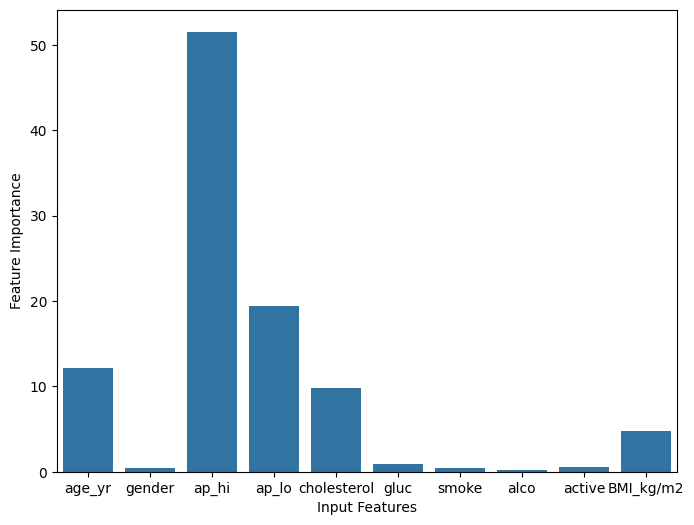

In [38]:
plt.figure(figsize=(8,6))
sns.barplot(y=fimp,x=inp_f)
plt.xlabel('Input Features')
plt.ylabel('Feature Importance')


In [40]:
# Last Model testing on test data
from sklearn.metrics import classification_report

print(classification_report(y_test,rf1.predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.71      0.76      0.73      6400
         1.0       0.75      0.69      0.72      6632

    accuracy                           0.73     13032
   macro avg       0.73      0.73      0.73     13032
weighted avg       0.73      0.73      0.73     13032



In [41]:
y_scores = rf1.predict_proba(X_test)[:,1]
y_scores

array([0.7158351 , 0.88414254, 0.79198507, ..., 0.84010269, 0.15779208,
       0.18236733], shape=(13032,))

In [42]:
# ROC- AUC curve 
from sklearn.metrics import roc_curve
fpr,tpr,thresholds = roc_curve(y_test,y_scores)

Text(0, 0.5, 'tpr')

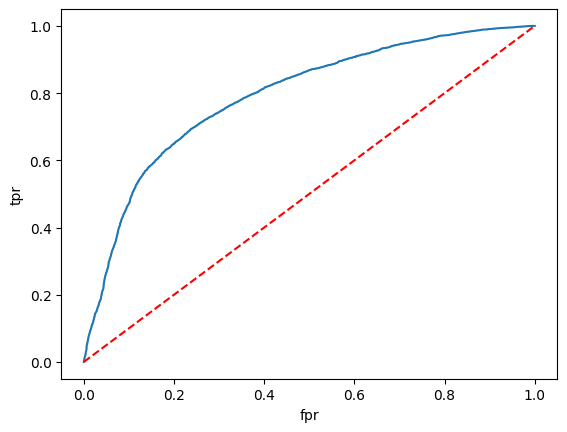

In [48]:
sns.lineplot(x=fpr,y=tpr)
plt.plot([0,1],[0,1],linestyle='--',color='red')
plt.xlabel('fpr')
plt.ylabel('tpr')

In [50]:
thresholds

array([       inf, 0.91318655, 0.91181066, ..., 0.03906483, 0.03752334,
       0.03590111], shape=(5098,))

In [51]:
diff = (tpr-fpr)
best_thresh = diff.argmax()
best_t = thresholds[best_thresh]
best_t

np.float64(0.49984802105795084)

In [53]:
y_pred_04 = (rf1.predict_proba(X_test)[:,1] > 0.4).astype(int)
print(classification_report(y_test, y_pred_03))


NameError: name 'y_pred_03' is not defined

In [60]:
# threshold 0.3 
y_pred_03 = (rf1.predict_proba(X_test)[:,1] > 0.3).astype(int)
print(classification_report(y_test, y_pred_03))

              precision    recall  f1-score   support

         0.0       0.79      0.44      0.57      6400
         1.0       0.62      0.89      0.73      6632

    accuracy                           0.67     13032
   macro avg       0.71      0.67      0.65     13032
weighted avg       0.71      0.67      0.65     13032



In [61]:
# threshold 0.35
y_pred_035 = (rf1.predict_proba(X_test)[:,1] > 0.35).astype(int)
print(classification_report(y_test, y_pred_035))

              precision    recall  f1-score   support

         0.0       0.77      0.54      0.64      6400
         1.0       0.66      0.85      0.74      6632

    accuracy                           0.70     13032
   macro avg       0.71      0.69      0.69     13032
weighted avg       0.71      0.70      0.69     13032



In [ ]:
# threshold 0.4
y_pred_04 = (rf1.predict_proba(X_test)[:,1] > 0.4).astype(int)
print(classification_report(y_test, y_pred_04))

              precision    recall  f1-score   support

         0.0       0.75      0.63      0.68      6400
         1.0       0.69      0.80      0.74      6632

    accuracy                           0.71     13032
   macro avg       0.72      0.71      0.71     13032
weighted avg       0.72      0.71      0.71     13032

